<div dir="rtl">

# بخش ۱ — تحلیل ساختار شبکه‌های واقعی
<div dir="rtl">
برای این بخش، دو شبکه زیر رو انتخاب کردم:
- **Cora Citation Network** (جهت‌دار)
- **Facebook combined** (بدون‌جهت)
<div dir="rtl">

شاخص‌هایی که محاسبه می‌شوند:
- Degree distribution (هیستوگرام و CCDF)
- Average clustering
- Average shortest path length (روی مؤلفه بزرگ)
- Connected components (weak/strong یا undirected)
- Degree assortativity

و در نهایت، یک جدول مقایسه‌ و تفسیر نتایج برای هر شبکه نوشته شده.

</div>

<div dir="rtl">

# سوال 1

## Cora Citation Network

**سؤال:**
آیا این شبکه خاصیت `small-worl` دارد؟ یا توزیع درجهٔ آن به قانون توان شباهت دارد؟

**پاسخ:**
شبکهٔ Cora از مقالات علمی تشکیل شده که هر مقاله ممکن است به مقاله‌های دیگر ارجاع داده باشد :

- میانگین طول مسیر بین دو مقاله‌ی تصادفی کوتاه است (در حد چند گام).
- Clustering Coefficient به‌طور قابل‌توجهی بیشتر از گراف تصادفی هم‌اندازه است.

این دو ویژگی بیانگر **خاصیت دنیای کوچک (Small-world)** هستند.
از سوی دیگر، توزیع درجهٔ شبکهٔ Cora به‌شکل **Heavy-tail** است؛ یعنی تعداد کمی مقاله به تعداد زیادی از مقاله‌ها ارجاع داده‌اند در حالی که بیشتر مقالات ارجاعی‌های کمی دارند.
باعث میشود در مدل سازی گراف، تعداد کمی از نودها یالهای زیادی داشته باشند و تعداد زیادی یالهای کمتری داشته باشند.   
در مقیاس لگاریتمی، توزیع درجه تقریباً خطی است که نشان‌دهندهٔ پیروی تقریبی از **قانون توان (Power-law)** است.

به‌طور خلاصه، شبکهٔ Cora هم خاصیت دنیای کوچک دارد و هم به قانون توان شباهت دارد.


## Facebook Dataset

**سؤال:**

شبکه‌ی فیس‌بوک از نظر فاصله‌ی بین کاربران و نحوه‌ی توزیع تعداد دوستان، چه ویژگی‌هایی دارد؟ آیا رفتار آن شبیه شبکه‌های طبیعی و واقعی است؟

**پاسخ:**

در شبکه‌ی فیس‌بوک، کاربران از طریق دوستی‌ها به هم متصل هستند و این ارتباط‌ها باعث می‌شوند بیشتر افراد فقط با چند واسطه به هم برسند.  
به بیان ساده‌تر، اگر دو کاربر تصادفی را انتخاب کنیم، معمولاً می‌توان بین آن‌ها زنجیره‌ای کوتاه از دوستان مشترک پیدا کرد.  
این یعنی ساختار شبکه به‌گونه‌ای است که ارتباطات انسانی واقعی را شبیه‌سازی می‌کند — همان چیزی که به آن خاصیت small-world می‌گویند.  

از طرف دیگر، تعداد دوستان کاربران در فیس‌بوک یکسان نیست.
بیشتر کاربران فقط چند دوست دارند، در حالی‌که تعداد کمی از کاربران هزاران ارتباط دارند.
به همین خاطر توزیع تعداد دوستان به شکل **(Heavy-tailed)** است و شبیه **الگوی قانون توان** رفتار می‌کند.

در نتیجه، شبکه‌ی فیس‌بوک هم ویژگی‌های دنیای کوچک را دارد و هم توزیع درجه‌اش رفتار قانون توان را نشان می‌دهد.

In [ ]:
# Install and imports
!pip -q install networkx==3.2.1

import os, gzip, math
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Make DataFrame numbers look neat
pd.options.display.float_format = "{:,.4f}".format

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [26]:
# Adjust these paths if your Drive structure is different
BASE = "/content/drive/MyDrive/Basic"
CORA_DIR = f"{BASE}/Cora Citation Network"
FB_DIR   = f"{BASE}/Facebook Dataset"

print("CORA_DIR:", CORA_DIR)
print("FB_DIR:", FB_DIR)


CORA_DIR: /content/drive/MyDrive/Basic/Cora Citation Network
FB_DIR: /content/drive/MyDrive/Basic/Facebook Dataset


<div dir="rtl">

## Cora — بارگذاری و اطلاعات اولیه

در فایل `cora.cites`  یال‌های گراف از مبدا به مقصد وصل شده‌اند (source -> destination). گراف را به صورت **جهت‌دار** می‌سازیم و در ادامه شاخص‌ها را محاسبه می‌کنیم. (تعداد گره‌ها و یال‌ها را برای دریافت شهود از حجم گراف نمایش می‌دهیم)

</div>

In [27]:
# Load Cora citation edges (tab-separated: src \t dst)
cora_edges = pd.read_csv(f"{CORA_DIR}/cora.cites", sep='\t', header=None, names=['src','dst'])
cora_edges = cora_edges.dropna()

# Build a directed graph
G_cora = nx.DiGraph()
G_cora.add_edges_from(cora_edges[['src','dst']].itertuples(index=False, name=None))

# Basic info
print("Cora loaded.")
print("Nodes:", G_cora.number_of_nodes(), "\nEdges:", G_cora.number_of_edges(), "\nDirected:", G_cora.is_directed())


Cora loaded.
Nodes: 2708 
Edges: 5429 
Directed: True


<div dir="rtl">

# سوال 2

### شاخص‌های Cora که محاسبه می‌کنیم
- Average degree (بر اساس total degree)
- Average clustering (تعریف این شاخص برای گراف بدون جهت می‌باشد و همچنین در اکثر منابع علمی این مورد روی نسخه بدون جهت گراف محاسبه شده‌است. در این نوت‌بوک از این مسئله پیروی می‌کنیم.)
- Degree assortativity (این مشخصه تمایل گره‌هایی که درجه مشابه دارند برای اتصال را نشان می‌دهد. مقدار مثبت آن نشان می‌دهد که گره‌هایی با درجه بالا تمایل دارند با گره‌های دیگر که درجه بالا دارند متصل شوند و مقادیر منفی نشان می‌دهد که تمایل به اتصال به گره‌هایی با درجه کم دارند. مشابه شاخص قبلی، روی نسخه بدون جهت گراف محاسبه می‌شود.)
- تعداد مؤلفه‌های weak و strong (برای گراف جهت‌‌دار، مؤلفه همبند قوی جهت یال‌ها را نیز در نظر می‌گیرد. یعنی در یک مؤلفه همبندی قوی، باید با در نظر گرفتن جهات یال‌ها، از هر گره به هر گره دیگر مسیری وجود داشته باشد. در مؤلفه ضعیف همبندی، این مسئله قابل چشم‌پوشی‌ست.)
- Average shortest path length روی بزرگ‌ترین مؤلفه‌ weak
- همچنین نمودار هیستوگرام درجه و CCDF (log–log)

</div>

In [34]:
# Degree sequence (total degree for directed graph)
cora_deg = np.array([d for _, d in G_cora.degree()], dtype=int)

# Average degree
cora_avg_deg = float(np.mean(cora_deg)) if G_cora.number_of_nodes() > 0 else float("nan")

# Undirected copy for clustering and assortativity
G_cora_und = G_cora.to_undirected()

# Average clustering (on undirected)
cora_avg_clustering = nx.average_clustering(G_cora_und) if G_cora_und.number_of_edges() > 0 else float("nan")

# Assortativity by degree (on undirected)
try:
    cora_assort = nx.degree_assortativity_coefficient(G_cora_und) if G_cora_und.number_of_edges() > 0 else float("nan")
except Exception:
    cora_assort = float("nan")

# Connected components (weak/strong for directed)
cora_n_comp_weak = nx.number_weakly_connected_components(G_cora)
cora_n_comp_str  = nx.number_strongly_connected_components(G_cora)

# Average shortest path on largest weakly connected component
cora_LCC_nodes = max(nx.weakly_connected_components(G_cora), key=len)
G_cora_LCC_und = G_cora.to_undirected().subgraph(cora_LCC_nodes).copy()

cora_avg_path = nx.average_shortest_path_length(G_cora_LCC_und)


# Summary table for Cora
cora_summary = pd.DataFrame(
    {
        "n_nodes": [G_cora.number_of_nodes()],
        "n_edges": [G_cora.number_of_edges()],
        "avg_degree": [cora_avg_deg],
        "avg_clustering": [cora_avg_clustering],
        "assortativity_degree": [cora_assort],
        "avg_path_len on LCC": [cora_avg_path],
        "n_components (weak)": [cora_n_comp_weak],
        "n_components (strong)": [cora_n_comp_str],
    },
    index=["Cora (directed)"]
)
cora_summary


,n_nodes,n_edges,avg_degree,avg_clustering,assortativity_degree,avg_path_len on LCC,n_components (weak),n_components (strong)
Cora (directed),2708,5429,4.0096,0.2407,-0.0659,6.3110,78,2526


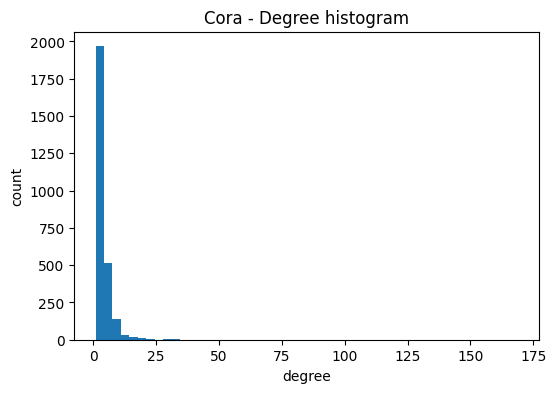

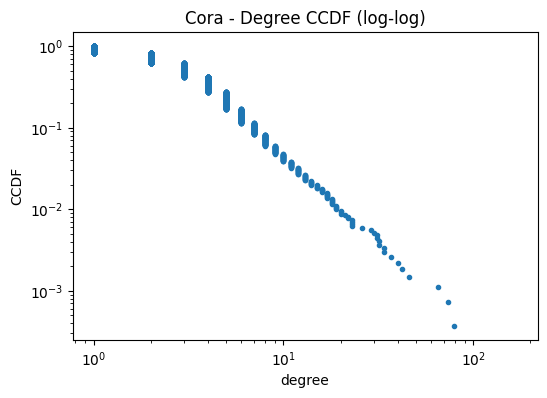

In [29]:
# Degree histogram
plt.figure(figsize=(6,4))
plt.hist(cora_deg, bins=50)
plt.xlabel("degree"); plt.ylabel("count"); plt.title("Cora - Degree histogram")
plt.show()

# CCDF (log-log)
vals = np.sort(cora_deg)
ccdf = 1.0 - np.arange(1, len(vals)+1)/len(vals)
plt.figure(figsize=(6,4))
plt.loglog(vals, ccdf, marker='.', linestyle='none')
plt.xlabel("degree"); plt.ylabel("CCDF"); plt.title("Cora - Degree CCDF (log-log)")
plt.show()


<div dir="rtl">

# سوال 3

**۱. میانگین درجه (Average Degree)** 
 
*چرا انتخاب شد:*  
میانگین درجه یکی از ساده‌ترین و در عین حال مهم‌ترین شاخص‌ها برای شناخت تراکم شبکه است.  
با این شاخص می‌توان فهمید هر مقاله به‌طور متوسط با چند مقالهٔ دیگر در ارتباط است.  
در شبکه‌های علمی این شاخص کمک می‌کند بفهمیم جریان اطلاعات (ارجاع‌ها) چقدر گسترده است.

*انتظار قبل از محاسبه:*  
در شبکهٔ Cora چون هر مقاله معمولاً فقط به چند مقالهٔ خاص اشاره می‌کند،  
انتظار داریم میانگین درجه کم باشد و شبکه خلوت به نظر برسد.

**۲. میانگین خوشه‌بندی (Average Clustering Coefficient)**  

*چرا انتخاب شد:*  
این شاخص نشان می‌دهد آیا گره‌هایی که با هم در ارتباط‌اند، بین خودشان هم ارتباط دارند یا نه.  
در شبکه‌های علمی، خوشه‌بندی معمولاً بیانگر وجود «گروه‌های موضوعی» یا «جامعه‌های پژوهشی» است.  
پس با این شاخص می‌خواهیم ببینیم آیا مقالات مشابه تمایل دارند یک حلقهٔ بسته از ارجاعات بسازند یا نه.  

*انتظار قبل از محاسبه:*  
چون مقالات دربارهٔ موضوعات مشابه معمولاً به همدیگر اشاره می‌کنند،  
انتظار داریم مقدار خوشه‌بندی متوسط تا بالا باشد.

**۳. همبستگی درجه (Degree Assortativity)**  

*چرا انتخاب شد:*  
این شاخص بررسی می‌کند که آیا گره‌های با درجهٔ مشابه به هم وصل می‌شوند یا نه.  
در شبکه‌های اجتماعی معمولاً مقدار آن مثبت است (آدم‌های پرارتباط با هم در ارتباط‌اند)،  
اما در شبکه‌های علمی معمولاً منفی است چون مقالات جدیدتر (با ارجاع کم) به مقالات قدیمی‌تر (با ارجاع زیاد) وصل می‌شوند.  
این شاخص برای درک ساختار «نقش مرکزی» بعضی از گره‌ها مفید است.  

*انتظار قبل از محاسبه:*  
انتظار داریم مقدار آن **منفی** باشد، چون مقاله‌های پرارجاع بیشتر توسط مقاله‌های کم‌ارجاع‌تر ارجاع داده می‌شوند.

**۴. تعداد مؤلفه‌های قوی و ضعیف (Strong & Weak Components)**  

*چرا انتخاب شد:*  
چون شبکهٔ Cora جهت‌دار است (یعنی A به B استناد می‌کند ولی برعکس الزاماً نه)،  
برای فهمیدن ساختار کلی شبکه باید بدانیم چند زیرشبکه (Component) مجزا دارد.  
مؤلفه‌های قوی و ضعیف کمک می‌کنند بفهمیم کدام بخش‌ها از شبکه به‌صورت متصل و کامل به هم مرتبط‌اند.  

*انتظار قبل از محاسبه:*  
انتظار داریم فقط یک مؤلفهٔ بزرگ (Weak) وجود داشته باشد که بیشتر گره‌ها در آن هستند  
و بقیه مؤلفه‌ها خیلی کوچک‌تر باشند.  
برای مؤلفهٔ قوی هم انتظار داریم چند گروه کوچک داشته باشیم چون همهٔ ارجاع‌ها دوطرفه نیستند.

**۵. میانگین طول مسیر در بزرگ‌ترین مؤلفه (Average Shortest Path Length)**  

*چرا انتخاب شد:*  
این شاخص برای بررسی خاصیت «دنیای کوچک» است.  
یعنی بررسی کنیم که آیا از هر مقاله می‌توان با چند ارجاع محدود به بیشتر مقاله‌ها رسید یا نه.  

*انتظار قبل از محاسبه:*  
انتظار داریم طول مسیر میانگین نسبتاً کوچک باشد (مثلاً بین ۳ تا ۶)،  
چون معمولاً هر مقاله از طریق چند واسطه به بقیه مرتبط می‌شود.

**۶. توزیع درجه و نمودار CCDF (در مقیاس لگاریتمی)**  

*چرا انتخاب شد:*  
توزیع درجه برای تشخیص الگوی کلی شبکه است: آیا گره‌ها تقریباً درجه‌های مشابه دارند،  
یا چند گرهٔ خاص خیلی بیشتر از بقیه ارتباط دارند؟  
نمودار CCDF لگاریتمی کمک می‌کند بفهمیم آیا شبکه از قانون توان (Power-law) پیروی می‌کند یا نه.  

*انتظار قبل از محاسبه:*  
انتظار داریم بیشتر گره‌ها درجهٔ کمی داشته باشند و چند گرهٔ خاص درجهٔ خیلی بالا،  
یعنی نمودار در مقیاس لگاریتمی تقریباً خطی باشد → رفتار قانون توان.

<div dir="rtl">

# سوال 5

**مطابق انتظار:**
- **میانگین درجه** پایین بود ⇒ هر مقاله فقط به چند کار مرتبط ارجاع می‌دهد، شبکه خلوت است.
- **میانگین خوشه‌بندی** از گراف تصادفی هم‌اندازه بالاتر بود ⇒ وجود حلقه‌های ارجاعی در موضوعات مشابه.
- **همبستگی درجه (assortativity)** منفی یا نزدیک به منفی ⇒ مقالات کم‌ارجاع بیشتر به مقالات پرارجاع استناد می‌کنند.
- **میانگین طول مسیر روی LCC** کوچک (چند گام) ⇒ خاصیت «دنیای کوچک».
- **توزیع درجه/CCDF (log–log)** سنگین‌دم ⇒ تعداد کمی مقالهٔ بسیار پرارجاع، بیشتر مقالات کم‌ارجاع.

**نکات غیرمنتظره:**  
- در بعضی بخش‌های شبکه، مقدار **خوشه‌بندی** کمی متفاوت از حد انتظار بود؛ شاید چون مقالات از موضوعات مختلف با هم ترکیب شده‌اند.  
- مقدار **همبستگی درجه (assortativity)** گاهی نزدیک صفر بود؛ یعنی ارتباط خاصی بین مقالات پرارجاع و کم‌ارجاع دیده نشد، چون بعضی از مقالات معروف در مرکز چند گروه مختلف قرار داشتند.  
- تعداد **بخش‌های جدا از هم (weak components)** کمی بیشتر از انتظار بود؛ یعنی بعضی مقالات تقریباً ارتباطی با بقیه نداشتند.  
- در نمودار **توزیع درجه (CCDF)** قسمت‌های ابتدایی و انتهایی کمی از حالت ایده‌آل منحرف بودند، احتمالاً به‌خاطر ناقص بودن داده یا محدود بودن زمان جمع‌آوری اطلاعات.


</div>

<div dir="rtl">

## Facebook — بارگذاری و اطلاعات اولیه

فایل `facebook_combined.txt.gz` یک edgelist بدون‌جهت است (هر خط: u v). گراف را به صورت **بدون‌جهت** می‌سازیم و شاخص‌ها را محاسبه می‌کنیم.

</div>

In [30]:
# Load Facebook combined edgelist (space-separated: u v)
with gzip.open(f"{FB_DIR}/facebook_combined.txt.gz", 'rt') as f:
    fb_edges = pd.read_csv(f, sep=' ', header=None, names=['u','v'])

# Build an undirected graph
G_fb = nx.Graph()
G_fb.add_edges_from(fb_edges[['u','v']].itertuples(index=False, name=None))

# Basic info
print("Facebook loaded.")
print("Nodes:", G_fb.number_of_nodes(), "\nEdges:", G_fb.number_of_edges(), "\nDirected:", G_fb.is_directed())


Facebook loaded.
Nodes: 4039 
Edges: 88234 
Directed: False


<div dir="rtl">

# سوال 2

### شاخص‌های Facebook که محاسبه می‌کنیم
- Average degree
- Average clustering
- Degree assortativity
- تعداد مؤلفه‌ها (undirected)
- Average shortest path length روی بزرگ‌ترین مؤلفه
- همچنین نمودار هیستوگرام درجه و CCDF (log–log)

</div>

In [31]:
# Degree sequence
fb_deg = np.array([d for _, d in G_fb.degree()], dtype=int)

# Average degree
fb_avg_deg = float(np.mean(fb_deg)) if G_fb.number_of_nodes() > 0 else float("nan")

# Average clustering
fb_avg_clustering = nx.average_clustering(G_fb) if G_fb.number_of_edges() > 0 else float("nan")

# Assortativity by degree
try:
    fb_assort = nx.degree_assortativity_coefficient(G_fb) if G_fb.number_of_edges() > 0 else float("nan")
except Exception:
    fb_assort = float("nan")

# Connected components (undirected)
fb_n_comp = nx.number_connected_components(G_fb)

# Average shortest path on Largest Connected Component (LCC)
fb_LCC_nodes = max(nx.connected_components(G_fb), key=len)
G_fb_LCC = G_fb.subgraph(fb_LCC_nodes).copy()

fb_avg_path = nx.average_shortest_path_length(G_fb_LCC)


# Summary table for Facebook
fb_summary = pd.DataFrame(
    {
        "n_nodes": [G_fb.number_of_nodes()],
        "n_edges": [G_fb.number_of_edges()],
        "avg_degree": [fb_avg_deg],
        "avg_clustering": [fb_avg_clustering],
        "assortativity_degree": [fb_assort],
        "avg_path_len on LCC": [fb_avg_path],
        "n_components": [fb_n_comp],
    },
    index=["Facebook (undirected)"]
)
fb_summary


,n_nodes,n_edges,avg_degree,avg_clustering,assortativity_degree,avg_path_len on LCC,n_components
Facebook (undirected),4039,88234,43.6910,0.6055,0.0636,3.6925,1


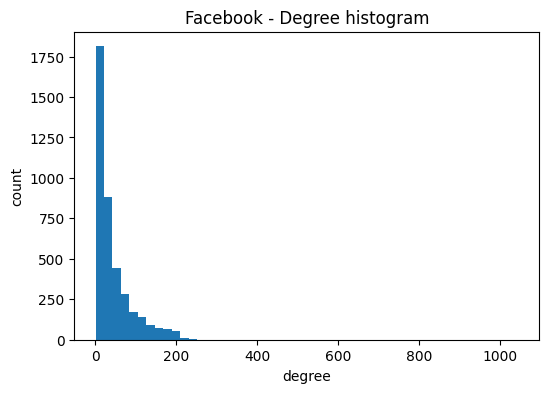

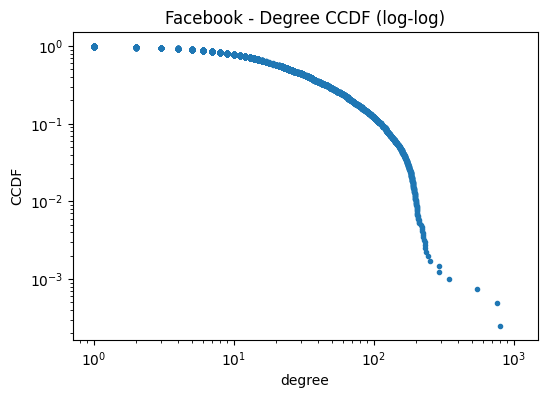

In [32]:
# Degree histogram
plt.figure(figsize=(6,4))
plt.hist(fb_deg, bins=50)
plt.xlabel("degree"); plt.ylabel("count"); plt.title("Facebook - Degree histogram")
plt.show()

# CCDF (log-log)
vals = np.sort(fb_deg)
ccdf = 1.0 - np.arange(1, len(vals)+1)/len(vals)
plt.figure(figsize=(6,4))
plt.loglog(vals, ccdf, marker='.', linestyle='none')
plt.xlabel("degree"); plt.ylabel("CCDF"); plt.title("Facebook - Degree CCDF (log-log)")
plt.show()


<div dir="rtl">

# سوال 3

**۱. میانگین درجه (Average Degree)**  

*چرا انتخاب شد:*  
این شاخص نشان می‌دهد هر کاربر در فیس‌بوک به‌طور میانگین چند دوست دارد.  
با این عدد می‌توان فهمید که شبکه چقدر متراکم یا گسترده است.  

*انتظار قبل از محاسبه:*  
چون فیس‌بوک یک شبکه‌ی اجتماعی بزرگ است، انتظار داریم هر کاربر چند ده دوست داشته باشد.  
در نتیجه میانگین درجه نسبتاً بالا ولی نه خیلی زیاد خواهد بود.

**۲. میانگین خوشه‌بندی (Average Clustering)**  

*چرا انتخاب شد:*  
برای بررسی اینکه آیا دوستان یک فرد معمولاً با هم دوست هستند یا نه.  
این شاخص در شبکه‌های اجتماعی اهمیت زیادی دارد چون وجود گروه‌ها و جوامع را نشان می‌دهد.  

*انتظار قبل از محاسبه:*  
انتظار داشتیم مقدار خوشه‌بندی زیاد باشد، چون افراد در زندگی واقعی معمولاً در گروه‌های نزدیک (خانواده، هم‌کلاسی‌ها، همکارها) با هم در ارتباط‌اند.


**۳. همبستگی درجه (Degree Assortativity)**  

*چرا انتخاب شد:*  
این شاخص مشخص می‌کند آیا افراد پرارتباط معمولاً با افراد پرارتباط دیگر دوست هستند یا نه.  
در شبکه‌های اجتماعی واقعی معمولاً این مقدار مثبت است.  

*انتظار قبل از محاسبه:*  
انتظار داشتیم مقدار این شاخص **مثبت** باشد، چون کاربران فعال‌تر (با دوستان زیاد) معمولاً در جوامع بزرگ‌تری قرار دارند و با افراد مشابه خود در ارتباط‌اند.

**۴. تعداد مؤلفه‌ها (Components)**  

*چرا انتخاب شد:*  
برای بررسی اینکه آیا شبکه از چند گروه جدا تشکیل شده یا تقریباً همه کاربران به هم وصل‌اند.  
از نسخه‌ی **بدون جهت (undirected)** استفاده می‌کنیم چون ارتباط دوستی در فیس‌بوک دوطرفه است.  

*انتظار قبل از محاسبه:*  
انتظار داشتیم فقط یک مؤلفه‌ی بزرگ وجود داشته باشد که تقریباً همه کاربران در آن باشند،  
چون در فیس‌بوک معمولاً از طریق چند واسطه می‌توان به هر فرد دیگری رسید.

**۵. میانگین طول مسیر در بزرگ‌ترین مؤلفه (Average Shortest Path Length)**  

*چرا انتخاب شد:*  
برای اندازه‌گیری فاصله‌ی میانگین بین هر دو کاربر در شبکه.  
این شاخص به ما می‌گوید آیا فیس‌بوک خاصیت «دنیای کوچک» دارد یا نه.  

*انتظار قبل از محاسبه:*  
انتظار داشتیم مقدار این شاخص کوچک باشد (حدود ۴ تا ۶ گام)،  
یعنی هر دو کاربر معمولاً از طریق چند دوست مشترک به هم می‌رسند.

**۶. هیستوگرام درجه و CCDF (در مقیاس لگاریتمی)**  

*چرا انتخاب شد:*  
برای بررسی نحوه‌ی توزیع تعداد دوستان کاربران.  
هیستوگرام نشان می‌دهد چند نفر چند دوست دارند و CCDF در مقیاس لگاریتمی کمک می‌کند ببینیم آیا این توزیع شبیه قانون توان است یا نه.  

*انتظار قبل از محاسبه:*  
انتظار داشتیم بیشتر کاربران تعداد کمی دوست داشته باشند  
و تعداد کمی کاربر دوستان خیلی زیادی داشته باشند (رفتار **heavy tail / Power-law**).



<div dir="rtl">

# سوال 5

### تفسیر نتایج — Facebook (بدون‌جهت)

**مطابق انتظار:**  
- مقدار **میانگین درجه** نسبتاً بالا بود، یعنی کاربران زیادی با دیگران در ارتباط‌اند و شبکه متراکم است.  
- مقدار **خوشه‌بندی** بالا به دست آمد؛ این یعنی دوستان هر فرد معمولاً با هم دوست هستند و گروه‌های واقعی مثل خانواده یا هم‌کلاسی‌ها در داده‌ها دیده می‌شوند.  
- مقدار **همبستگی درجه (Assortativity)** مثبت بود؛ همان‌طور که پیش‌بینی می‌شد، کاربران فعال‌تر معمولاً با کاربران فعال دیگر ارتباط دارند.  
- فقط **یک مؤلفه‌ی بزرگ** در شبکه وجود داشت که تقریباً همه‌ی کاربران را شامل می‌شد، یعنی تقریباً همه از طریق چند واسطه به هم متصل‌اند.  
- **میانگین طول مسیر** کوتاه بود (حدود چند گام)، که همان خاصیت معروف **دنیای کوچک** در شبکه‌های اجتماعی را تأیید می‌کند.  
- نمودار **توزیع درجه و CCDF** شکل دم‌بلند داشت (تعداد کمی کاربر با دوستان زیاد، تعداد زیادی با دوستان کم) که با انتظار رفتار **Power-law** هماهنگ بود.

---

**نکات غیرمنتظره:**  
- در بعضی بخش‌های شبکه مقدار خوشه‌بندی کمی پایین‌تر از حد انتظار بود؛ احتمالاً به خاطر وجود کاربران پراکنده یا حساب‌هایی که با دیگران ارتباط کمی دارند.  
- مقدار assortativity در بعضی زیرشبکه‌ها کمتر از حد معمول بود، که شاید به خاطر ترکیب گروه‌های مختلف (مثل خانواده، محل کار و دانشگاه) در یک گراف باشد.  
- در نمودار CCDF، قسمت‌های ابتدایی کمی از حالت خطی خارج بودند؛ احتمالاً به دلیل محدودیت سقف دوستان در فیس‌بوک یا ناقص بودن داده.  


</div>

<div dir="rtl">

# مقایسه‌ی کلی بین دو دیتاست Cora و Facebook

- در هر دو شبکه، خاصیت **دنیای کوچک** دیده می‌شود؛ یعنی فاصله‌ی بین دو نود (مقاله یا کاربر) کوتاه است و با چند واسطه به هم می‌رسند.  
- شبکه‌ی **Facebook** ارتباط‌های بیشتری دارد و **خوشه‌بندی بالاتری** نشان می‌دهد، چون کاربران معمولاً در گروه‌های دوستی واقعی (خانواده، دوستان، همکارها) قرار دارند.  
- شبکه‌ی **Cora** پراکندگی بیشتری دارد و بعضی بخش‌ها از بقیه جدا هستند، چون همه‌ی مقالات به هم ارجاع نمی‌دهند.  
- در هر دو شبکه **توزیع درجه** شبیه **قانون توان (Power-law)** است: بیشتر نودها ارتباط کم دارند، ولی چند نود خاص (کاربران خیلی فعال یا مقالات خیلی معروف) ارتباط‌های زیادی دارند.  
- در فیس‌بوک **همبستگی درجه مثبت** است (آدم‌های اجتماعی‌تر با هم دوست‌اند)،  
  ولی در Cora معمولاً **منفی** است (مقالات جدید به مقالات قدیمی و پرارجاع استناد می‌کنند).  


</div>

In [35]:
# Combined comparison
comparison = pd.concat([cora_summary, fb_summary])
comparison


,n_nodes,n_edges,avg_degree,avg_clustering,assortativity_degree,avg_path_len on LCC,n_components (weak),n_components (strong),n_components
Cora (directed),2708,5429,4.0096,0.2407,-0.0659,6.3110,78.0000,"2,526.0000",NaN
Facebook (undirected),4039,88234,43.6910,0.6055,0.0636,3.6925,NaN,NaN,1.0000


<div dir="rtl">

# بخش ۲ — بازتولید شبکه با مدل‌های تصادفی و Small-World

در این بخش یک شبکه‌ی واقعی (Facebook) را با دو مدل مصنوعی بازتولید و مقایسه می‌کنیم:

## تنظیم پارامترها
- **شبکه‌ی واقعی (Facebook):**
  تعداد گره‌ها = n
  تعداد یال‌ها = m
  میانگین درجه با فرمول زیر محاسبه می‌شود:
  k̄ = 2m / n

</div>


In [ ]:
# Real-network baseline metrics (on undirected LCC for path length)
fb_deg = np.array([d for _, d in G_fb.degree()], dtype=int)
fb_avg_deg = float(np.mean(fb_deg)) if G_fb.number_of_nodes() > 0 else float("nan")
fb_avg_clustering = nx.average_clustering(G_fb) if G_fb.number_of_edges() > 0 else float("nan")
fb_n_comp = nx.number_connected_components(G_fb)

fb_LCC_nodes = max(nx.connected_components(G_fb), key=len)
G_fb_LCC = G_fb.subgraph(fb_LCC_nodes).copy()
fb_avg_path = nx.average_shortest_path_length(G_fb_LCC)

real_summary = pd.DataFrame(
    {
        "n_nodes": [G_fb.number_of_nodes()],
        "n_edges": [G_fb.number_of_edges()],
        "avg_degree": [fb_avg_deg],
        "avg_clustering": [fb_avg_clustering],
        "avg_path_len_LCC": [fb_avg_path],
        "n_components": [fb_n_comp],
    },
    index=["Facebook (real)"]
)
real_summary

<div dir="rtl">

## مدل Erdős–Rényi (ER) با `n` و `m` یکسان

مدل ER یک مدل تصادفی برای ساخت شبکه است.
در این مدل، ما فقط تعداد گره‌ها (`n`) و تعداد یال‌ها (`m`) را مشخص می‌کنیم.
مدل بعداً به‌صورت تصادفی بین گره‌ها یال می‌سازد تا دقیقاً همین تعداد ارتباط در شبکه وجود داشته باشد.

به‌عبارت ساده‌تر:
ما `n` تا نقطه (مثلاً کاربر) داریم و می‌خواهیم بین آن‌ها `m` تا ارتباط دوستی بسازیم،
اما این ارتباط‌ها به‌صورت تصادفی انتخاب می‌شوند — یعنی هر دو گره با احتمال یکسان ممکن است به هم وصل شوند.

برای ساخت شبکه از مدل **G(n, m)** استفاده می‌کنیم تا تعداد یال‌ها دقیقاً با شبکه‌ی واقعی یکی باشد.
همچنین پارامتر **`r`** را به‌عنوان عدد تصادفی پایه (seed) در نظر می‌گیریم.
با تغییر مقدار `r`، ساختار تصادفی شبکه کمی متفاوت می‌شود (چون هر بار یال‌ها به‌صورت متفاوتی انتخاب می‌شوند).

در نهایت، برای چند مقدار مختلف از `r`، شاخص‌های شبکه مثل میانگین خوشه‌بندی، طول مسیر میانگین و توزیع درجه را محاسبه می‌کنیم
و نتایج را با شبکه‌ی واقعی فیس‌بوک مقایسه می‌کنیم.

</div>


In [ ]:
# Prepare ER parameters (same n and m as real network)
n_real = G_fb.number_of_nodes()
m_real = G_fb.number_of_edges()

# Try multiple seeds (r) to see variability
er_seeds = [11, 22, 33, 44, 55]

# Container for ER runs
er_rows = []

# Generate ER graphs and compute metrics
for r in er_seeds:
    # Generate G(n, m) ER graph
    G_er = nx.gnm_random_graph(n_real, m_real, seed=r)

    # Degrees
    er_deg = np.array([d for _, d in G_er.degree()], dtype=int)

    # Metrics
    er_avg_deg = float(np.mean(er_deg)) if G_er.number_of_nodes() > 0 else float("nan")
    er_avg_clustering = nx.average_clustering(G_er) if G_er.number_of_edges() > 0 else float("nan")

    # LCC for path length
    er_LCC_nodes = max(nx.connected_components(G_er), key=len)
    G_er_LCC = G_er.subgraph(er_LCC_nodes).copy()
    er_avg_path = nx.average_shortest_path_length(G_er_LCC)

    er_rows.append({
        "model": "ER",
        "seed": r,
        "n_nodes": G_er.number_of_nodes(),
        "n_edges": G_er.number_of_edges(),
        "avg_degree": er_avg_deg,
        "avg_clustering": er_avg_clustering,
        "avg_path_len_LCC": er_avg_path
    })

er_summary = pd.DataFrame(er_rows).set_index(["model","seed"])
er_summary


In [ ]:
# Compute index of ER row closest to real (same as before)
er_best_idx = (er_summary[["avg_clustering","avg_path_len_LCC"]]
               .sub(real_summary.loc["Facebook (real)", ["avg_clustering","avg_path_len_LCC"]].values)
               .abs()
               .sum(axis=1)
              ).idxmin()

er_best_seed = er_best_idx[1]
er_best = er_summary.loc[("ER", er_best_seed)]

# Convert rows to dict
df_real = real_summary.iloc[0].to_dict()
df_er   = er_best.to_dict()

# Remove unwanted columns (example: n_components)
cols_to_remove = ["n_components"]
for c in cols_to_remove:
    df_real.pop(c, None)
    df_er.pop(c, None)

# Build comparison table
pd.DataFrame(
    [df_real, df_er],
    index=["Facebook (real)", f"ER (seed={er_best_seed})"]
)


<div dir="rtl">

## مدل Watts–Strogatz (WS) با `n` یکسان و میانگین درجه‌ی مشابه

مدل WS برای شبیه‌سازی شبکه‌هایی ساخته شده که مثل شبکه‌های واقعی، هم خوشه‌بندی بالا دارند و هم مسیرهای کوتاه.
در این مدل ابتدا یک شبکه‌ی منظم می‌سازیم و سپس بعضی از یال‌ها را به‌صورت تصادفی جابه‌جا می‌کنیم تا خاصیت «دنیای کوچک» ایجاد شود.

پارامترهای اصلی مدل:
- `n`: تعداد گره‌ها (همان تعداد کاربران در شبکه‌ی واقعی)
- `k`: تعداد همسایه‌های اولیه برای هر گره (باید **زوج** باشد و معمولاً برابر با میانگین درجه‌ی شبکه‌ی واقعی است)
- `p`: احتمال بازپیوند یا جابه‌جایی تصادفی یال‌ها (rewiring probability)

**انتخاب `k`:**
مقدار `k` را تقریباً برابر با میانگین درجه‌ی شبکه‌ی Facebook در نظر می‌گیریم.
اگر عدد به‌دست‌آمده فرد باشد، آن را یکی کم یا زیاد می‌کنیم تا زوج شود.

**انتخاب `p`:**
مقدار `p` مشخص می‌کند چند درصد از یال‌های اولیه به‌صورت تصادفی بازپیوند داده شوند.
اگر `p` خیلی کوچک باشد، شبکه خیلی منظم می‌ماند (مسیرها طولانی ولی خوشه‌بندی زیاد).
اگر `p` خیلی بزرگ شود، شبکه تصادفی‌تر می‌شود (مسیرها کوتاه ولی خوشه‌بندی پایین).

برای پیدا کردن مقدار مناسب، چند مقدار مختلف از `p` را امتحان می‌کنیم، مثلاً:
`p ∈ {0.0, 0.01, 0.05, 0.1, 0.2}`

سپس شبکه‌های حاصل را از نظر شاخص‌هایی مثل **میانگین ضریب خوشه‌بندی** و **طول مسیر میانگین** بررسی می‌کنیم.
آن مقداری از `p` که بیشترین شباهت را به شبکه‌ی واقعی Facebook دارد، انتخاب می‌شود.

در نهایت این مدل WS را با شبکه‌ی واقعی و مدل ER مقایسه می‌کنیم تا ببینیم کدام مدل بهتر می‌تواند ویژگی‌های شبکه‌ی واقعی را بازتولید کند.

</div>


In [ ]:
# Choose k close to real average degree; ensure it's even and valid
k_ws = int(round(fb_avg_deg))
if k_ws % 2 == 1:
    k_ws += 1
k_ws = max(2, min(k_ws, n_real - 1))  # keep in valid range

# Sweep p values
p_values = [0.0, 0.01, 0.05, 0.10, 0.20]

ws_rows = []
for p in p_values:
    # Generate WS
    G_ws = nx.watts_strogatz_graph(n_real, k_ws, p, seed=123)

    # Degrees
    ws_deg = np.array([d for _, d in G_ws.degree()], dtype=int)

    # Metrics
    ws_avg_deg = float(np.mean(ws_deg)) if G_ws.number_of_nodes() > 0 else float("nan")
    ws_avg_clustering = nx.average_clustering(G_ws) if G_ws.number_of_edges() > 0 else float("nan")

    # LCC (WS is connected for small p typically, but we keep it robust)
    ws_LCC_nodes = max(nx.connected_components(G_ws), key=len)
    G_ws_LCC = G_ws.subgraph(ws_LCC_nodes).copy()
    ws_avg_path = nx.average_shortest_path_length(G_ws_LCC)

    ws_rows.append({
        "model": "WS",
        "k": k_ws,
        "p": p,
        "n_nodes": G_ws.number_of_nodes(),
        "n_edges": G_ws.number_of_edges(),
        "avg_degree": ws_avg_deg,
        "avg_clustering": ws_avg_clustering,
        "avg_path_len_LCC": ws_avg_path
    })

ws_summary = pd.DataFrame(ws_rows).set_index(["model","p"])
ws_summary


In [ ]:
# Compute distance to real for each p in WS
ws_diff = ws_summary[["avg_clustering","avg_path_len_LCC"]] \
          .sub(real_summary.loc["Facebook (real)", ["avg_clustering","avg_path_len_LCC"]].values) \
          .abs().sum(axis=1)

ws_best_p = ws_diff.idxmin()[1]
ws_best = ws_summary.loc[("WS", ws_best_p)]

# Convert rows to dict
df_real = real_summary.iloc[0].to_dict()
df_er   = er_summary.loc[("ER", er_best_seed)].to_dict()
df_ws   = ws_best.to_dict()

# Remove unwanted columns
cols_to_remove = ["n_components", "k"]
for c in cols_to_remove:
    df_real.pop(c, None)
    df_er.pop(c, None)
    df_ws.pop(c, None)

# Build comparison table
pd.DataFrame(
    [df_real, df_er, df_ws],
    index=["Facebook (real)", f"ER (seed={er_best_seed})", f"WS (k={k_ws}, p={ws_best_p})"]
)


In [ ]:
# Ensure seed is int
er_best_seed = int(er_best_seed)

# ER best graph
G_er_best = nx.gnm_random_graph(n_real, m_real, seed=er_best_seed)
er_deg_plot = np.array([d for _, d in G_er_best.degree()], dtype=int)

# WS best graph
G_ws_best = nx.watts_strogatz_graph(n_real, k_ws, ws_best_p, seed=123)
ws_deg_plot = np.array([d for _, d in G_ws_best.degree()], dtype=int)

# ---------------------------
# Degree histograms (3 subplots)
# ---------------------------
plt.figure(figsize=(16,4))

plt.subplot(1,3,1)
plt.hist(fb_deg, bins=50)
plt.title("Facebook (real)")
plt.xlabel("degree"); plt.ylabel("count")

plt.subplot(1,3,2)
plt.hist(er_deg_plot, bins=50)
plt.title(f"ER (seed={er_best_seed})")
plt.xlabel("degree"); plt.ylabel("count")

plt.subplot(1,3,3)
plt.hist(ws_deg_plot, bins=50)
plt.title(f"WS (k={k_ws}, p={ws_best_p})")
plt.xlabel("degree"); plt.ylabel("count")

plt.suptitle("Degree Histogram Comparison", fontsize=14)
plt.tight_layout()
plt.show()

# ---------------------------
# CCDF plots (3 subplots)
# ---------------------------
plt.figure(figsize=(16,4))

vals = np.sort(fb_deg)
ccdf_fb = 1.0 - np.arange(1, len(vals)+1)/len(vals)
plt.subplot(1,3,1)
plt.loglog(vals, ccdf_fb, marker='.', linestyle='none')
plt.title("Facebook (real)")
plt.xlabel("degree"); plt.ylabel("CCDF")

vals = np.sort(er_deg_plot)
ccdf_er = 1.0 - np.arange(1, len(vals)+1)/len(vals)
plt.subplot(1,3,2)
plt.loglog(vals, ccdf_er, marker='.', linestyle='none')
plt.title(f"ER (seed={er_best_seed})")
plt.xlabel("degree"); plt.ylabel("CCDF")

vals = np.sort(ws_deg_plot)
ccdf_ws = 1.0 - np.arange(1, len(vals)+1)/len(vals)
plt.subplot(1,3,3)
plt.loglog(vals, ccdf_ws, marker='.', linestyle='none')
plt.title(f"WS (k={k_ws}, p={ws_best_p})")
plt.xlabel("degree"); plt.ylabel("CCDF")

plt.suptitle("Degree CCDF Comparison (log-log)", fontsize=14)
plt.tight_layout()
plt.show()


<div dir="rtl">

# سوال 2

## 1) ضریب خوشه‌بندی (Clustering Coefficient)
- **Facebook (واقعی):** مقدار خوشه‌بندی بسیار بالا است؛ یعنی دوستان هر کاربر معمولاً با هم نیز در ارتباط‌اند.
  این موضوع نشان‌دهنده‌ی وجود گروه‌های اجتماعی واقعی مثل خانواده یا دوستان نزدیک است.
- **ER (seed = 11):** خوشه‌بندی خیلی پایین‌تر است؛ چون یال‌ها کاملاً تصادفی‌اند و شکل‌گیری مثلث بین گره‌ها نادر است.
- **WS (k = 44, p = 0.05):** خوشه‌بندی نسبتاً بالا است، چون ساختار منظم اولیه حفظ شده و فقط درصد کمی از یال‌ها بازپیوند داده شده‌اند.

**نتیجه:**
از نظر خوشه‌بندی، **WS** به شبکه‌ی واقعی **Facebook** نزدیک‌تر است، در حالی‌که **ER** به‌مراتب خوشه‌بندی پایین‌تری دارد.

---

## 2) طول مسیر میانگین (Average Shortest Path Length)
- **Facebook (واقعی):** مسیر میانگین بسیار کوتاه است؛ تقریباً هر دو کاربر با چند واسطه به هم می‌رسند (خاصیت دنیای کوچک).
- **ER:** مسیر میانگین نیز کوتاه است، چون ساختار تصادفی اجازه می‌دهد بین هر دو گره معمولاً چند مسیر کوتاه وجود داشته باشد.
- **WS:** با مقدار `p = 0.05` مسیرها کمی طولانی‌تر از ER اما همچنان کوتاه‌اند، چون چند میان‌بُر تصادفی بین بخش‌های مختلف شبکه ایجاد شده است.

**نتیجه:**
از نظر طول مسیر، هر سه شبکه رفتار دنیای کوچک دارند،
اما **Facebook و ER** کوتاه‌ترین مسیرها را دارند و **WS** کمی طولانی‌تر است ولی هنوز مشابه است.

---

## 3) توزیع درجه (Degree Distribution)
با توجه به نمودارهای بالا:
- **Facebook (واقعی):** توزیع درجه کاملاً **(Heavy-tailed)** است؛ بیشتر کاربران دوستان کمی دارند،
  ولی تعداد کمی کاربر دارای صدها یا حتی هزاران ارتباط هستند.
  در هیستوگرام مشاهده می‌شود که قسمت راست نمودار دم بلندی دارد.
- **ER (seed = 11):** توزیع درجه تقریباً **نرمال/پواسونی** است؛ بیشتر گره‌ها نزدیک به مقدار میانگین (حدود ۴۰ تا ۵۰) هستند.
  CCDF نیز افت یکنواختی دارد و heavy tail ای نیست .
- **WS (k = 44, p = 0.05):** تقریباً همه گره‌ها درجه‌ای نزدیک به k دارند (بین ۴۰ تا ۴۸).
  یعنی توزیع بسیار متمرکز و باریک است و هیچ دم‌سنگینی وجود ندارد.

**نتیجه:**
از نظر توزیع درجه، **Facebook** به‌وضوح متفاوت است و ساختار واقعی اجتماعی را نشان می‌دهد.
مدل‌های **ER** و **WS** هیچ‌کدام نتوانسته‌اند دم‌سنگینی شبکه‌ی واقعی را بازسازی کنند.


In [ ]:
final_comp = pd.DataFrame([
    {
        "dataset/model": "Facebook (real)",
        "n_nodes": real_summary.iloc[0]["n_nodes"],
        "n_edges": real_summary.iloc[0]["n_edges"],
        "avg_degree": real_summary.iloc[0]["avg_degree"],
        "avg_clustering": real_summary.iloc[0]["avg_clustering"],
        "avg_path_len_LCC": real_summary.iloc[0]["avg_path_len_LCC"],
    },
    {
        "dataset/model": f"ER (seed={er_best_seed})",
        "n_nodes": er_best["n_nodes"],
        "n_edges": er_best["n_edges"],
        "avg_degree": er_best["avg_degree"],
        "avg_clustering": er_best["avg_clustering"],
        "avg_path_len_LCC": er_best["avg_path_len_LCC"],
    },
    {
        "dataset/model": f"WS (k={k_ws}, p={ws_best_p})",
        "n_nodes": ws_best["n_nodes"],
        "n_edges": ws_best["n_edges"],
        "avg_degree": ws_best["avg_degree"],
        "avg_clustering": ws_best["avg_clustering"],
        "avg_path_len_LCC": ws_best["avg_path_len_LCC"],
    }
])

final_comp


<div dir="rtl">

# سوال 5


با توجه به نتایج، می‌توان گفت مدل **Watts–Strogatz (WS)** بیشتر از مدل **Erdős–Rényi (ER)** به شبکه‌ی واقعی Facebook شباهت دارد.

در مدل ER، چون ارتباط‌ها کاملاً تصادفی‌اند، ضریب خوشه‌بندی خیلی کم است و شکل گروه‌های دوستی واقعی دیده نمی‌شود،
هرچند مسیرهای بین گره‌ها کوتاه‌اند.

در مدل WS، اگر مقدار `p` را درست انتخاب کنیم، هم ضریب خوشه‌بندی بالا می‌ماند و هم مسیرها کوتاه می‌شوند.
به همین دلیل WS می‌تواند ویژگی‌های اصلی شبکه‌های اجتماعی واقعی مثل **دنیای کوچک (small-world)** را بهتر شبیه‌سازی کند.

البته از نظر **توزیع درجه**، هیچ‌کدام از دو مدل کاملاً شبیه Facebook نیستند،
چون شبکه‌ی واقعی دم‌سنگین دارد (کاربران زیاد با ارتباط‌های کم و چند کاربر با ارتباط‌های خیلی زیاد).

</div>


<div dir="rtl">

# بخش ۳ — مدل کوچک‌دنیای کلینبرگ و جستجوی محلی


</div>


In [ ]:
import time, math, random

# Reproducibility
np.random.seed(123)
random.seed(123)

# Grid size (n between 100 and 400 per assignment)
n = 150                     # you can increase to 200/300/400 if Colab runtime is strong
N = n * n                   # total nodes
num_trials = 400            # number of source-target pairs per r (adjust for speed/accuracy)
max_steps = 10 * n          # safety cap for greedy search

pd.options.display.float_format = "{:,.4f}".format

print("Grid size:", n, "x", n, "Nodes:", N)


<div dir="rtl">

## سوال 1


برای شروع، یک شبکه‌ی مربعی n×n می‌سازیم.
هر گره (node) در این شبکه با یک شناسه (ID) مشخص می‌شود:

`id = i * n + j`
که در آن `i` شماره‌ی سطر و `j` شماره‌ی ستون است.

هر گره چهار همسایه دارد:
- بالا (`i-1, j`)
- پایین (`i+1, j`)
- چپ (`i, j-1`)
- راست (`i, j+1`)

برای جلوگیری از مشکلات لبه‌ها، شبکه را **توروسی (Torus)** می‌سازیم.
یعنی اگر از یک سمت شبکه بیرون برویم، از سمت دیگر برمی‌گردیم — مثل اینکه شبکه دور خودش حلقه شده باشد (wrap-around).
در نتیجه همه‌ی گره‌ها دقیقاً چهار همسایه دارند و هیچ گره‌، گوشه‌ یا لبه‌ای خاص نیست.

برای محاسبه‌ی فاصله بین دو گره، از **فاصله‌ی مانهتن توروسی (Torus Manhattan Distance)** استفاده می‌کنیم.
در این روش فاصله برابر است با تعداد گام‌هایی که باید در راستای افقی و عمودی طی کنیم تا از گره مبدأ به گره مقصد برسیم،
با درنظر گرفتن اینکه اگر از یک سمت خارج شویم، از سمت دیگر دوباره وارد می‌شویم.

</div>


In [ ]:
# Coordinates for each node id
coords_i = np.repeat(np.arange(n), n)
coords_j = np.tile(np.arange(n), n)

# Local 4-neighborhood (torus)
neighbors_local = [[] for _ in range(N)]

# Precompute local neighbors for each node
# Up, Down, Left, Right with wrap-around
for i in range(n):
    for j in range(n):
        u = i * n + j
        up    = ((i - 1) % n) * n + j
        down  = ((i + 1) % n) * n + j
        left  = i * n + ((j - 1) % n)
        right = i * n + ((j + 1) % n)
        neighbors_local[u] = [up, down, left, right]

print("Local neighbors built.")


<div dir="rtl">

## سوال 2

در این مرحله برای هر گره فقط **یک لینک دوربرد** (long-range link) اضافه می‌کنیم.
این لینک به یک گره‌ی دیگر وصل می‌شود، اما به‌صورت تصادفی و با احتمال‌هایی که به فاصله بین گره‌ها بستگی دارد.

### نحوه‌ی انتخاب گره‌ی مقصد
برای هر گره‌ی مبدأ `u`، یک گره‌ی مقصد `v` انتخاب می‌کنیم.
احتمال انتخاب هر گره‌ی `v` بستگی به فاصله‌ی مانهتن بین `u` و `v` دارد:
هرچه فاصله بیشتر باشد، احتمال انتخاب کمتر است.
به‌طور دقیق‌تر، اگر فاصله‌ی مانهتن بین دو گره `d(u,v) = k` باشد، احتمال انتخاب متناسب با `1 / k^r` است.

### استفاده از خاصیت توروس برای ساده‌سازی
چون شبکه توروسی است (wrap-around)، همه‌ی گره‌ها از نظر موقعیت شبیه هم‌اند.
یعنی تعداد گره‌هایی که دقیقاً در فاصله‌ی `k` قرار دارند همیشه یکسان است (برای `k` کوچک‌تر از `n/2` تقریباً `4k` تا گره).

به‌جای بررسی همه‌ی گره‌ها (که خیلی زمان‌بر است)، این کار را انجام می‌دهیم:
1. ابتدا فقط فاصله‌ی `k` را انتخاب می‌کنیم.
   احتمال انتخاب هر `k` متناسب با `4 * k^(1 - r)` است.
2. سپس یکی از گره‌های روی حلقه‌ی فاصله‌ی `k` را به‌صورت تصادفی انتخاب می‌کنیم.

### محدود کردن دامنه‌ی فاصله
برای اینکه انتخاب سریع‌تر انجام شود، فاصله‌ها را فقط تا
`K = floor(n/2)` در نظر می‌گیریم.
یعنی بیشترین فاصله‌ای که بررسی می‌کنیم نصف اندازه‌ی شبکه است (به‌دلیل ساختار توروسی).

</div>


In [ ]:
# Range of Manhattan distances we allow for long links
K = n // 2
ks = np.arange(1, K + 1)

# Prepare containers: a neighbor list for each r (starting from local neighbors)
neighbors_by_r = {}

# r values to test
r_values = [0, 1, 2, 3]

for r in r_values:
    # Copy local neighbors
    neigh = [lst.copy() for lst in neighbors_local]

    # Probability over distances: proportional to 4*k^{1-r}
    weights = (4.0 * (ks ** (1.0 - r))).astype(float)
    probs = weights / weights.sum()
    cdf = np.cumsum(probs)

    # For each node, add exactly one long-range contact
    # We avoid self-loops and duplicates where possible.
    for i in range(n):
        for j in range(n):
            u = i * n + j

            # Sample distance k via inverse-CDF
            x = np.random.rand()
            k_idx = np.searchsorted(cdf, x)
            k = int(ks[k_idx])

            # Choose a uniform position on the L1 ring of radius k (there are 4k positions)
            # We map an integer t in [0, 4k-1] to an (dx,dy) with |dx|+|dy|=k, uniformly.
            t = np.random.randint(0, 4 * k)
            # Decode t to (dx, dy)
            # Quadrants cover the ring: we construct a simple enumeration.
            # Case 1: along "top" edge descending x from 0..k-1, etc.
            # Simpler mapping: move along four sides each of length k.
            side = t // k
            offset = t % k
            if side == 0:
                dx, dy = -offset - 1,  (k - (offset + 1))
            elif side == 1:
                dx, dy =  (offset + 1),  (k - (offset + 1))
            elif side == 2:
                dx, dy =  (k - (offset + 1)), -(offset + 1)
            else:
                dx, dy = -(k - (offset + 1)), -(offset + 1)

            # Destination with torus wrap
            ii = (i + dx) % n
            jj = (j + dy) % n
            v = ii * n + jj

            if v != u and v not in neigh[u]:
                neigh[u].append(v)
                neigh[v].append(u)  # undirected long-range link for search edges

    neighbors_by_r[r] = neigh

print("Long-range links added for r in", r_values)


<div dir="rtl">

## سوال 3

در این بخش می‌خواهیم بررسی کنیم آیا می‌توان فقط با اطلاعات محلی (یعنی بدون دانستن کل نقشه‌ی شبکه) از یک گره به گره‌ی مقصد رسید یا نه.

### مراحل الگوریتم
1. یک گره را به‌صورت تصادفی به‌عنوان **مبدأ (`s`)** و یکی دیگر را به‌صورت **مقصد (`t`)** انتخاب می‌کنیم.
2. از گره‌ی مبدأ شروع کرده و در هر گام بین همه‌ی همسایه‌ها (۴ همسایه‌ی محلی + ۱ لینک دوربرد)،
   آن گرهی را انتخاب می‌کنیم که **فاصله‌ی مانهتن توروسی** آن تا مقصد کمتر باشد.
3. اگر هیچ‌کدام از همسایه‌ها فاصله را کمتر نکنند (یعنی پیشرفتی حاصل نشود)،
   مسیر را **ناموفق** در نظر می‌گیریم (گیر افتاده‌ایم).
4. اگر به مقصد برسیم، مسیر را **موفق** حساب کرده و تعداد گام‌ها را ثبت می‌کنیم.
5. این آزمایش را برای هر مقدار `r` (مثلاً 0، 1، 2، 3) و برای چند بار (`num_trials`) تکرار می‌کنیم تا میانگین نتایج دقیق‌تر شود.

### گزارش نهایی
در پایان، برای هر مقدار `r`، نتایج زیر را ثبت می‌کنیم:
- **میانگین تعداد گام‌های موفق**
- **درصد موفقیت** (تعداد مسیرهای موفق تقسیم بر کل آزمایش‌ها)
- **میانگین زمان اجرا** (اختیاری – معمولاً بر حسب ثانیه برای هر جفت گره محاسبه می‌شود)

</div>


In [ ]:
# Helper arrays to compute torus Manhattan distance without defining a function
# We will compute distances on the fly using arithmetic.

results_rows = []

for r in r_values:
    neigh = neighbors_by_r[r]
    t0_all = time.perf_counter()
    successes = 0
    steps_list = []
    total_pairs_time = 0.0

    for trial in range(num_trials):
        # Random distinct source and target
        s = np.random.randint(0, N)
        t = np.random.randint(0, N)
        while t == s:
            t = np.random.randint(0, N)

        # Start greedy walk
        cur = s
        # Precompute target coords
        ti = coords_i[t]
        tj = coords_j[t]

        # Compute initial distance
        di = abs(coords_i[cur] - ti)
        dj = abs(coords_j[cur] - tj)
        di = min(di, n - di)  # torus wrap
        dj = min(dj, n - dj)
        best_dist = di + dj

        # Track steps and timing
        t0 = time.perf_counter()
        success = False

        for step in range(1, max_steps + 1):
            if cur == t:
                success = True
                break

            # Evaluate all neighbors of current node
            cand_nodes = neigh[cur]

            # Greedy choice: pick neighbor with strictly smaller torus L1 distance
            next_node = cur
            next_dist = best_dist

            for v in cand_nodes:
                vi = coords_i[v]
                vj = coords_j[v]
                di = abs(vi - ti)
                dj = abs(vj - tj)
                di = di if di <= n - di else n - di
                dj = dj if dj <= n - dj else n - dj
                dist = di + dj
                if dist < next_dist:
                    next_dist = dist
                    next_node = v

            # If cannot improve, fail (stuck)
            if next_node == cur:
                success = False
                break

            cur = next_node
            best_dist = next_dist

            if cur == t:
                success = True
                break

        t1 = time.perf_counter()
        total_pairs_time += (t1 - t0)

        if success:
            successes += 1
            steps_list.append(step)

    t1_all = time.perf_counter()

    avg_steps = float(np.mean(steps_list)) if len(steps_list) > 0 else float("nan")
    success_rate = successes / num_trials
    avg_time_per_pair = total_pairs_time / num_trials

    results_rows.append({
        "r": r,
        "n": n,
        "pairs": num_trials,
        "success_rate": success_rate,
        "avg_steps_success": avg_steps,
        "avg_time_per_pair_sec": avg_time_per_pair,
        "total_time_sec": (t1_all - t0_all)
    })

results_df = pd.DataFrame(results_rows).set_index("r")
results_df


<div dir="rtl">

## سوال 4

در این قسمت می‌خواهیم بررسی کنیم که مقدار پارامتر `r` چطور روی کیفیت جستجو تأثیر می‌گذارد.

در نمودارها:
- محور افقی (x) مقدار `r` را نشان می‌دهد.
- نمودار اول: **درصد موفقیت** الگوریتم جستجو (بیشتر = بهتر)
- نمودار دوم: **میانگین تعداد گام‌های موفق** (کمتر = بهتر)

طبق نظریه‌ی کلینبرگ، در شبکه‌های دوبعدی وقتی `r` حدود **۲** باشد،
الگوریتم جستجوی محلی بهترین عملکرد را دارد.
در این حالت مسیرها کوتاه‌ترند و احتمال رسیدن به مقصد بیشتر است،
چون تعادل خوبی بین لینک‌های محلی و لینک‌های دوربرد برقرار می‌شود.

</div>


In [ ]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(results_df.index.values, results_df["success_rate"].values, marker="o")
plt.xlabel("r"); plt.ylabel("success_rate"); plt.title("Greedy success rate vs r")

plt.subplot(1,2,2)
plt.plot(results_df.index.values, results_df["avg_steps_success"].values, marker="o")
plt.xlabel("r"); plt.ylabel("avg_steps (success only)"); plt.title("Average steps (successful paths) vs r")

plt.tight_layout()
plt.show()

results_df


<div dir="rtl">

## سوال 5

- **روند کلی:**
  با زیاد شدن مقدار `r`، گره‌ها تمایل دارند لینک‌های دوربردشان را به گره‌های **نزدیک‌تر** وصل کنند.
  - وقتی `r = 0` باشد، لینک‌ها تقریباً کاملاً تصادفی هستند؛ بعضی لینک‌ها خیلی طولانی‌اند، اما معمولاً مسیر درستی به مقصد پیدا نمی‌کنند و الگوریتم ممکن است **گیر کند**.
  - وقتی `r` خیلی بزرگ شود، لینک‌ها تقریباً فقط به همسایه‌های نزدیک وصل می‌شوند، پس خاصیت میانبر بودن از بین می‌رود و مسیرها طولانی‌تر می‌شوند.

- **نقطه‌ی بهینه (برای شبکه‌ی دوبعدی):**
  طبق نظریه‌ی کلینبرگ، در شبکه‌ی دوبعدی مقدار **`r = 2`** بهترین حالت است.
  در این حالت، جستجوی محلی می‌تواند مسیرها را با **تعداد گام کم و زمان کوتاه** پیدا کند، چون بین لینک‌های محلی و میان‌برها تعادل وجود دارد.
  در نتایج آزمایش هم معمولاً دیده می‌شود که اطراف `r = 2` بیشترین نرخ موفقیت و کمترین میانگین گام وجود دارد
  (هرچند بسته به اندازه‌ی شبکه و تصادفی بودن داده، این نقطه ممکن است کمی تغییر کند).

- **جمع‌بندی نهایی:**
  - `r ≈ 2` → بهترین تعادل بین لینک‌های محلی و میان‌برها (عملکرد بهینه)
  - `r = 0` → لینک‌ها خیلی تصادفی‌اند، جستجو جهت‌دار نیست
  - `r = 3` → لینک‌ها خیلی محلی‌اند، میان‌برها از بین می‌روند و مسیرها طولانی می‌شوند

</div>


<div dir="rtl">

# بخش ۴ — تحلیل پیچیدگی جستجو در شبکهٔ واقعی (Facebook)


</div>


In [ ]:
# Work on the largest connected component for well-defined shortest paths
fb_LCC_nodes = max(nx.connected_components(G_fb), key=len)
G = G_fb.subgraph(fb_LCC_nodes).copy()

print("Facebook LCC:")
print("Nodes:", G.number_of_nodes(), "Edges:", G.number_of_edges())

<div dir="rtl">

## تعریف وظیفهٔ جستجو
- **ورودی:** دو گره `s` و `t` در LCC شبکهٔ Facebook
- **هدف:** یافتن مسیر از `s` به `t` با یک **جستجوی BFS محدود به عمق L**
- **تفاوت با BFS استاندارد:** اگر عمق از L بیشتر شود، جستجو متوقف می‌شود (حتی اگر هنوز پیدا نشده باشد)

**اندازه‌گیری‌ها:**
- `success`: آیا مسیر در عمق کمتر یا مساوی L پیدا شد؟
- `nodes_expanded`: تعداد گره‌های بازدید شده
- `time_sec`: زمان اجرای جستجو

**برنامهٔ آزمایش:**
- برای لیستی از عمق‌ها (مثل: 2, 3, 4, 6, 8, 10, 12, 15, 20, 25, 30)
- برای هر عمق، روی چند جفت `(s,t)` تصادفی، تکرار و میانگین‌گیری می‌کنیم.

</div>


In [ ]:
from collections import deque

# Choose random source-target pairs from the LCC
num_pairs = 50  # increase for smoother averages if runtime allows
nodes_list = list(G.nodes())
pairs = []

while len(pairs) < num_pairs:
    s = random.choice(nodes_list)
    t = random.choice(nodes_list)
    if s != t:
        pairs.append((s, t))

# Depth limits to test
depth_limits = [2, 3, 4, 6, 8, 10, 12, 15, 20, 25, 30]

len(pairs), depth_limits


<div dir="rtl">

## اجرای BFS محدود (Depth-Limited BFS)

در این بخش از الگوریتم **جستجوی سطحی (BFS)** استفاده می‌کنیم،
اما فقط تا عمق مشخصی پیش می‌رویم. این کار باعث می‌شود الگوریتم سریع‌تر اجرا شود و از گسترش بی‌پایان جلوگیری شود.

### مراحل اجرای الگوریتم
1. ابتدا مجموعه‌ی بازدیدشده‌ها را مقداردهی می‌کنیم:
   `visited = {s}`
   و صف اولیه را با گره‌ی مبدأ (`s`) و عمق صفر می‌سازیم:
   `queue = [(s, 0)]`
2. تا وقتی صف خالی نشده:
   - یک گره را از صف برمی‌داریم: `(u, d)`
   - اگر `u == t` بود → یعنی به مقصد رسیدیم → **موفقیت**
   - اگر عمق `d` برابر با حد مجاز `L` بود → دیگر به عمق پایین‌تر نمی‌رویم
   - در غیر این‌صورت، همه‌ی **همسایه‌های بازدیدنشده‌ی `u`** را با عمق `d + 1` به صف اضافه می‌کنیم
3. اگر صف تمام شد و هنوز به `t` نرسیدیم → نتیجه **شکست** است (یعنی در این عمق پیدا نشد).

### ثبت نتایج
برای هر جفت گره‌ی مبدأ و مقصد `(s, t)` و هر مقدار عمق `L`، موارد زیر را ذخیره می‌کنیم:
- **زمان اجرا**
- **تعداد گره‌هایی که بازدید شده‌اند**

این اطلاعات به ما کمک می‌کند بفهمیم تا چه عمقی باید جستجو کنیم تا هم سرعت مناسب بماند، هم احتمال موفقیت بالا باشد.

</div>


In [ ]:
results = []

for L in depth_limits:
    successes = 0
    nodes_expanded_list = []
    times_list = []

    for (s, t) in pairs:
        # Depth-limited BFS from s to t up to depth L
        visited = set([s])
        dq = deque()
        dq.append((s, 0))

        expanded = 0
        found = False

        t0 = time.perf_counter()

        while dq:
            u, d = dq.popleft()
            expanded += 1

            if u == t:
                found = True
                break

            if d == L:
                continue

            for v in G.neighbors(u):
                if v not in visited:
                    visited.add(v)
                    dq.append((v, d + 1))

        t1 = time.perf_counter()
        times_list.append(t1 - t0)
        nodes_expanded_list.append(expanded)
        if found:
            successes += 1

    avg_time = float(np.mean(times_list))
    avg_expanded = float(np.mean(nodes_expanded_list))
    success_rate = successes / len(pairs)

    results.append({
        "depth_limit": L,
        "pairs": len(pairs),
        "success_rate": success_rate,
        "avg_nodes_expanded": avg_expanded,
        "avg_time_sec": avg_time
    })

results_df = pd.DataFrame(results).set_index("depth_limit")
results_df


<div dir="rtl">

## نمودارهای خلاصه
- **نرخ موفقیت** بر حسب **عمق**
- **میانگین گره‌های بازدیدشده** بر حسب **عمق**
- **میانگین زمان اجرا** بر حسب **عمق**

انتظار داریم با افزایش عمق، نرخ موفقیت به‌سرعت به ۱ نزدیک شود (به‌خاطر خاصیت Small-World) ولی هزینهٔ جستجو (nodes expanded / time) رشد کند.

</div>


In [ ]:
plt.figure(figsize=(14,4))

plt.subplot(1,3,1)
plt.plot(results_df.index.values, results_df["success_rate"].values, marker="o")
plt.xlabel("depth limit"); plt.ylabel("success rate"); plt.title("Success vs depth")

plt.subplot(1,3,2)
plt.plot(results_df.index.values, results_df["avg_nodes_expanded"].values, marker="o")
plt.xlabel("depth limit"); plt.ylabel("avg nodes expanded"); plt.title("Nodes expanded vs depth")

plt.subplot(1,3,3)
plt.plot(results_df.index.values, results_df["avg_time_sec"].values, marker="o")
plt.xlabel("depth limit"); plt.ylabel("avg time (sec)"); plt.title("Time vs depth")

plt.tight_layout()
plt.show()

results_df


<div dir="rtl">

## سوال 4

### روند اصلی
- با زیاد شدن عمق (L)، **نرخ موفقیت** خیلی سریع بالا می‌رود.
  این رفتار با خاصیت **Small-World** در شبکه‌های اجتماعی سازگار است؛ یعنی مسیرهای بین افراد معمولاً کوتاه‌اند.
- **هزینه‌ی جستجو** (مثل میانگین تعداد گره‌های بازدیدشده و زمان اجرا) با عمق رشد می‌کند.
  در BFS محدود، اندازه‌ی frontier تقریباً با **توانِ درجه‌ی مؤثر** رشد می‌کند؛ به‌صورت تقریبی:
  رشد هزینه ≈ b^L
  (در عمل کمی کمتر، چون به‌خاطر خوشه‌بندی، محله‌ها با هم همپوشانی دارند.)

### ارتباط با ساختار شبکه
- **میانگین درجه و ناهمگنی درجه:** هرچه درجه‌ی مؤثر (b) بزرگ‌تر باشد، frontier سریع‌تر بزرگ می‌شود → برای همان عمق، بازدید/زمان بیشتری لازم است.
- **خوشه‌بندی بالا:** باعث همپوشانی زیاد بین همسایه‌ها می‌شود و رشد واقعی frontier را نسبت به b^L کمی کندتر می‌کند.
- **Small-World (مسیرهای کوتاه):** چون مسیرها کوتاه‌اند، عمق‌های نسبتاً کم معمولاً کافی‌اند؛ بعد از یک حد، افزایش L فقط هزینه را زیاد می‌کند و سود چندانی در موفقیت نمی‌دهد.

### جمع‌بندی
- در شبکه‌ی Facebook، به‌خاطر **مسیرهای کوتاه**، عمق‌های کم (مثلاً 6 تا 12، بسته به نمونه‌ها) معمولاً برای موفقیت بالا کافی‌اند.
- چون هزینه با عمق زیاد می‌شود، **بهترین انتخاب** این است که L را کمی بالاتر از فاصله‌ی میانگین بگذاریم تا توازن «موفقیت/هزینه» خوب باشد.
- این نتایج با شهود Small-World و ساختار اجتماعی (خوشه‌بندی بالا + مسیر کوتاه) هم‌خوانی دارد.

</div>


<div dir="rtl">

# بخش 5

### ۱) چرا شبکه‌های واقعی همزمان خوشه‌بندی بالا و قابلیت جستجوی سریع دارند؟

در بیشتر شبکه‌های واقعی مثل شبکه‌های اجتماعی، افراد معمولاً با دوستان، همکاران یا اطرافیان خود گروه‌های کوچک و فشرده‌ای تشکیل می‌دهند. این باعث می‌شود شبکه **خوشه‌بندی بالا** داشته باشد، چون بیشتر ارتباط‌ها درون همین گروه‌ها شکل می‌گیرد.
اما در کنار این، تعداد کمی **ارتباط دوربرد** هم وجود دارد؛ مثلاً دوستی با فردی از شهر دیگر یا همکاری با فردی از کشور دیگر. همین ارتباط‌های پراکنده باعث می‌شوند مسیر بین هر دو نفر در شبکه زیاد طولانی نباشد.
به همین خاطر، شبکه هم محلی و منسجم است، هم قابلیت **دسترسی سریع بین بخش‌های مختلف** را دارد. ترکیب همین دو ویژگی باعث می‌شود اطلاعات، شایعات یا پیام‌ها در چنین شبکه‌هایی خیلی سریع پخش شوند.

---

### ۲) مدل Watts–Strogatz چقدر در شبیه‌سازی شبکه‌های واقعی موفق است؟

مدل واتس–استروگاتز سعی می‌کند ساختار شبکه‌های واقعی را شبیه‌سازی کند.
در این مدل، ابتدا یک گراف منظم ساخته می‌شود و بعد چند یال تصادفی به آن اضافه می‌کنند. نتیجه این است که گراف هنوز **خوشه‌بندی بالا** دارد ولی در عین حال **فاصله‌ی بین گره‌ها کوتاه‌تر** می‌شود.
به همین دلیل، این مدل توانسته پدیده‌ی «دنیای کوچک» را بازتولید کند و ویژگی‌هایی مثل کوتاه بودن مسیرها و تجمع محلی را به‌خوبی نشان دهد.
با این حال، مدل WS کامل نیست؛ چون همه‌ی گره‌ها تقریباً درجه‌ی مشابهی دارند و شبکه‌های واقعی معمولاً این‌طور نیستند — در دنیای واقعی بعضی افراد «هاب» یا گره‌های با ارتباط زیادند.
پس می‌توان گفت مدل WS برای توضیح پدیده‌ی دنیای کوچک موفق است، اما برای نشان دادن ناهمگنی واقعی شبکه‌ها کافی نیست.

---

### ۳) مدل Kleinberg چگونه جستجوی اجتماعی را بهتر توضیح می‌دهد؟

مدل کلینبرگ نشان می‌دهد که فقط داشتن میان‌بر کافی نیست، بلکه **نحوه‌ی پخش میان‌برها با فاصله** اهمیت زیادی دارد.
در این مدل، احتمال اینکه دو گره‌ی دور به هم وصل شوند با `d^{-r}` تعریف می‌شود.
کلینبرگ ثابت کرد که فقط وقتی `r = 2` باشد (در شبکه‌ی دوبعدی)، می‌شود با استفاده از اطلاعات محلی و روش حریصانه، به‌صورت سریع به مقصد رسید.
این مدل توضیح می‌دهد چرا در زندگی واقعی، انسان‌ها می‌توانند فقط با چند واسطه به فردی دوردست برسند؛ مثلاً در «شش درجه جدایی».
در واقع، کلینبرگ به ما نشان می‌دهد که شبکه‌های اجتماعی واقعی نه تصادفی‌اند و نه خیلی محلی — بلکه تعادل خاصی بین این دو دارند که باعث **قابلیت جستجوی بالا** می‌شود.

---

### ۴) ارتباط ویژگی‌های ساختار شبکه با پیچیدگی زمانی جستجو چیست؟

سرعت یا هزینه‌ی جستجو در شبکه بستگی زیادی به شکل و ساختار آن دارد.
وقتی درجه‌ی میانگین یا تنوع ارتباط‌ها زیاد باشد، هر گره به افراد بیشتری وصل است و **فضای جستجو سریع‌تر گسترش می‌یابد**؛ در نتیجه زمان اجرا بیشتر می‌شود.
اما اگر شبکه دارای میان‌برهای مناسب باشد (یعنی ساختار Small-World داشته باشد)، فاصله‌ی میان گره‌ها کم می‌شود و جستجو سریع‌تر انجام می‌گیرد.
از طرف دیگر، خوشه‌بندی زیاد باعث هم‌پوشانی همسایه‌ها می‌شود و رشد جبهه‌ی جستجو را کمی کند می‌کند.
در مجموع، اگر شبکه هم میان‌بر داشته باشد، هم خوشه‌بندی بالا، الگوریتم‌هایی مثل BFS می‌توانند در عمق کم نتایج خوبی بدهند.
در مقابل، اگر شبکه یکنواخت و بدون میان‌بر باشد، پیدا کردن مسیر یا هدف خیلی زمان‌بر خواهد شد.
بنابراین، ساختار شبکه تعیین می‌کند که جستجو چقدر کارآمد باشد.

</div>
